In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import importlib
import seaborn as sns
%matplotlib inline

In [63]:
X = 6 * np.random.rand(100 , 1) - 3
y = 0.5 * X**2 + 1.5 * X + 2  + np.random.randn(100,1)

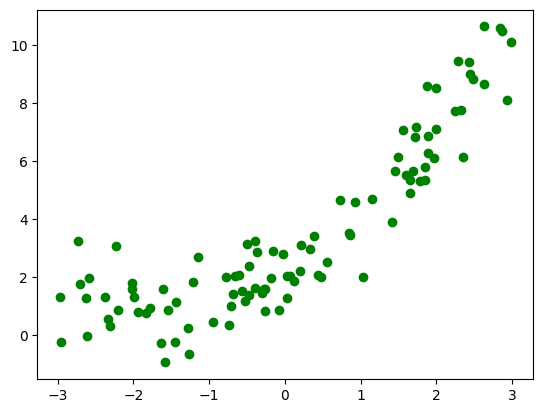

In [64]:
plt.scatter(X, y , c = 'g')
plt.xlabel = ('X dataset')
plt.ylabel = ('y dataset')

split

In [65]:
from sklearn.model_selection import train_test_split

In [66]:
X_train , X_test , y_train , y_test = train_test_split(X, y , test_size= 0.25 , random_state= 42)

implement linear regression

In [67]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [68]:
model.fit(X_train , y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [69]:
from sklearn.metrics import r2_score
score = r2_score(y_test , model.predict(X_test))
print(score) 

0.7135982928343966


## Lets Visualize this Model


Text(0, 0.5, 'Y')

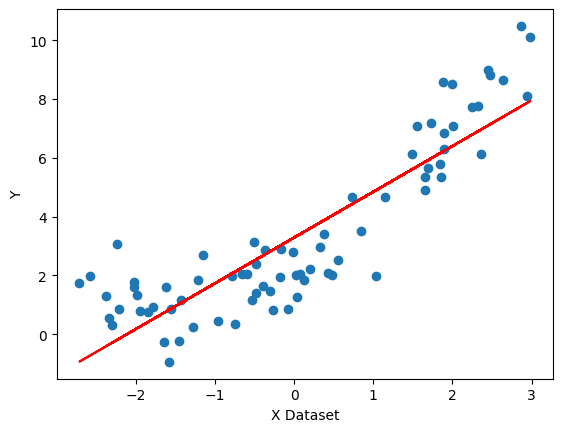

In [70]:
importlib.reload(plt)

plt.plot(X_train , model.predict(X_train) , c = 'r')
plt.scatter(X_train , y_train)
plt.xlabel('X Dataset')
plt.ylabel("Y")

## Lets apply polynomial transformation

In [71]:
from sklearn.preprocessing import PolynomialFeatures

In [72]:
ploy =  PolynomialFeatures(degree= 2 , include_bias=True)

In [73]:
X_train_poly = ploy.fit_transform(X_train)
X_test_poly = ploy.transform(X_test)

In [74]:
X_test_poly

array([[ 1.        ,  0.21613182,  0.04671297],
       [ 1.        ,  1.4596605 ,  2.13060877],
       [ 1.        , -0.71542165,  0.51182814],
       [ 1.        ,  2.63448373,  6.94050453],
       [ 1.        ,  1.71827324,  2.95246293],
       [ 1.        ,  1.96828897,  3.87416149],
       [ 1.        ,  0.86450216,  0.74736399],
       [ 1.        ,  1.78389503,  3.18228147],
       [ 1.        , -0.68134976,  0.46423749],
       [ 1.        , -1.26700471,  1.60530093],
       [ 1.        , -2.9702135 ,  8.82216826],
       [ 1.        ,  0.92830966,  0.86175883],
       [ 1.        ,  2.28690658,  5.22994169],
       [ 1.        , -2.60761139,  6.79963718],
       [ 1.        , -0.56526255,  0.31952176],
       [ 1.        ,  2.83718878,  8.04964015],
       [ 1.        , -0.39526092,  0.15623119],
       [ 1.        ,  1.41942841,  2.014777  ],
       [ 1.        ,  2.43171055,  5.91321622],
       [ 1.        , -2.95528813,  8.73372795],
       [ 1.        , -2.73660088,  7.488

In [75]:
X_test_poly

array([[ 1.        ,  0.21613182,  0.04671297],
       [ 1.        ,  1.4596605 ,  2.13060877],
       [ 1.        , -0.71542165,  0.51182814],
       [ 1.        ,  2.63448373,  6.94050453],
       [ 1.        ,  1.71827324,  2.95246293],
       [ 1.        ,  1.96828897,  3.87416149],
       [ 1.        ,  0.86450216,  0.74736399],
       [ 1.        ,  1.78389503,  3.18228147],
       [ 1.        , -0.68134976,  0.46423749],
       [ 1.        , -1.26700471,  1.60530093],
       [ 1.        , -2.9702135 ,  8.82216826],
       [ 1.        ,  0.92830966,  0.86175883],
       [ 1.        ,  2.28690658,  5.22994169],
       [ 1.        , -2.60761139,  6.79963718],
       [ 1.        , -0.56526255,  0.31952176],
       [ 1.        ,  2.83718878,  8.04964015],
       [ 1.        , -0.39526092,  0.15623119],
       [ 1.        ,  1.41942841,  2.014777  ],
       [ 1.        ,  2.43171055,  5.91321622],
       [ 1.        , -2.95528813,  8.73372795],
       [ 1.        , -2.73660088,  7.488

In [76]:
poly_Model = LinearRegression()
poly_Model.fit(X_train_poly , y_train)
y_pred = poly_Model.predict(X_test_poly)
score = r2_score(y_test , y_pred)
print(score)

0.9002622068615769


In [77]:
poly_Model.coef_

array([[0.        , 1.42714969, 0.43308948]])

In [78]:
poly_Model.intercept_

array([2.17878359])

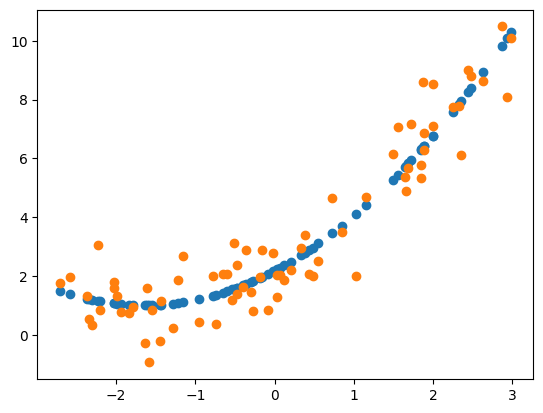

In [80]:
importlib.reload(plt)
plt.scatter(X_train , poly_Model.predict(X_train_poly) )
plt.scatter(X_train , y_train)

### Now what if we increse the degree

In [83]:
ploy =  PolynomialFeatures(degree= 3 , include_bias=True)

In [84]:
X_train_poly = ploy.fit_transform(X_train)
X_test_poly = ploy.transform(X_test)

In [85]:
X_train_poly

array([[ 1.00000000e+00,  1.49464745e+00,  2.23397099e+00,
         3.33899905e+00],
       [ 1.00000000e+00,  1.65252873e+00,  2.73085121e+00,
         4.51281009e+00],
       [ 1.00000000e+00, -1.92070233e-02,  3.68909743e-04,
        -7.08565803e-06],
       [ 1.00000000e+00,  2.63452931e+00,  6.94074468e+00,
         1.82855953e+01],
       [ 1.00000000e+00, -2.30470983e+00,  5.31168740e+00,
        -1.22418982e+01],
       [ 1.00000000e+00, -1.98915629e+00,  3.95674275e+00,
        -7.87057973e+00],
       [ 1.00000000e+00, -2.70967448e+00,  7.34233580e+00,
        -1.98953400e+01],
       [ 1.00000000e+00, -2.58108261e+00,  6.66198746e+00,
        -1.71951400e+01],
       [ 1.00000000e+00,  1.84705571e+00,  3.41161478e+00,
         6.30144255e+00],
       [ 1.00000000e+00, -2.02470819e+00,  4.09944325e+00,
        -8.30017631e+00],
       [ 1.00000000e+00,  2.00167828e+00,  4.00671594e+00,
         8.02015628e+00],
       [ 1.00000000e+00, -9.55352642e-01,  9.12698670e-01,
      

In [86]:
X_test_poly

array([[ 1.00000000e+00,  2.16131824e-01,  4.67129654e-02,
         1.00961584e-02],
       [ 1.00000000e+00,  1.45966050e+00,  2.13060877e+00,
         3.10996546e+00],
       [ 1.00000000e+00, -7.15421651e-01,  5.11828139e-01,
        -3.66172932e-01],
       [ 1.00000000e+00,  2.63448373e+00,  6.94050453e+00,
         1.82846463e+01],
       [ 1.00000000e+00,  1.71827324e+00,  2.95246293e+00,
         5.07313805e+00],
       [ 1.00000000e+00,  1.96828897e+00,  3.87416149e+00,
         7.62546934e+00],
       [ 1.00000000e+00,  8.64502163e-01,  7.47363990e-01,
         6.46097786e-01],
       [ 1.00000000e+00,  1.78389503e+00,  3.18228147e+00,
         5.67685609e+00],
       [ 1.00000000e+00, -6.81349757e-01,  4.64237492e-01,
        -3.16308102e-01],
       [ 1.00000000e+00, -1.26700471e+00,  1.60530093e+00,
        -2.03392383e+00],
       [ 1.00000000e+00, -2.97021350e+00,  8.82216826e+00,
        -2.62037233e+01],
       [ 1.00000000e+00,  9.28309664e-01,  8.61758831e-01,
      

In [88]:
poly_Model = LinearRegression()
poly_Model.fit(X_train_poly , y_train)
y_pred = poly_Model.predict(X_test_poly)
score = r2_score(y_test , y_pred)
print(score)

0.8838071138498188
